Sebelum dilakukan tahapan analisis sentimen, dataset perlu melalui proses **pelabelan (data labeling)** untuk menentukan kategori sentimen pada setiap ulasan.

# Import Dependencies

In [ ]:
# Import library yang dibutuhkan untuk preprocessing, visualisasi, dan sentiment analysis
import re 

import matplotlib.pyplot as plt 
import pandas as pd
import torch 
from tqdm import tqdm 
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline 

# Gunakan GPU jika tersedia, jika tidak gunakan CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [ ]:
# Fungsi untuk membersihkan teks review
def clean_text(text):
  text = str(text) # mengubah input menjadi string
  text = re.sub(r"\s+", " ", text)  # hapus spasi berlebih
  text = text.strip() # menghapus spasi di awal dan akhir teks
  return text

# Load Data

In [ ]:
# Memuat dataset review aplikasi BSI Mobile
df = pd.read_csv('review_bsi_mobile.csv')
df.sample(10)

,reviewId,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
16144,d9948779-83af-4503-b323-c8fe67bbfee3,Apk masih blum jelas perbaiki lagi buat login ...,1,0,6.22.0,2024-04-04 11:29:53,6.22.0
6923,06dbcdae-73d2-4769-a096-bdaba39c0990,Sudah 3 tahun pakai aplikasi BSI mobile. Selur...,5,0,NaN,2024-11-05 02:40:24,NaN
8758,1f03be71-1a76-4b13-be12-0fcc9e19c366,bikin sulit prosesnya,1,0,NaN,2024-10-10 14:18:26,NaN
12562,45c3390c-e0a5-41c8-8c6c-01d326b9fd3a,Saya bikin kesel dengan BSI ini sulit nya mint...,1,0,NaN,2024-08-06 13:13:32,NaN
8231,24292ef5-42fa-4268-8310-d4c81154cee4,Sering error,5,0,NaN,2024-10-17 11:12:30,NaN
1014,dd6776a7-b34f-44a1-9b98-8a408a212e7d,menyebalkan,1,0,6.26.1,2025-08-12 05:43:51,6.26.1
9634,8be92370-6331-4f8f-a655-281a652394b5,Sangat membantu,5,0,6.22.3,2024-09-24 08:19:03,6.22.3
19962,3454df32-0023-40f8-b6cc-2da5e5e6f662,TIAP HARI APLIKASI INI BERMASALAH SANGAT SANGA...,1,0,6.21.1,2024-01-12 21:47:56,6.21.1
19276,a04e9458-f3af-4299-bbe2-327e55e27baa,Sangat baik untuk aplikasi ini mempermudah dan...,5,0,NaN,2024-01-19 06:01:52,NaN
11455,148a5a04-331e-459b-b7f1-e37cd285cefa,Sering eror,3,0,6.22.2,2024-08-26 14:10:07,6.22.2


In [ ]:
# Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   content               19999 non-null  object
 2   score                 20000 non-null  int64 
 3   thumbsUpCount         20000 non-null  int64 
 4   reviewCreatedVersion  15940 non-null  object
 5   at                    20000 non-null  object
 6   appVersion            15940 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


# Data Pre-processing

Karena model yang digunakan merupakan **pretrained transformer model**, proses pembersihan teks tidak perlu dilakukan secara ekstensif. Model ini telah dilatih pada data teks mentah sehingga masih mampu menangani variasi teks seperti tanda baca atau huruf kapital.

In [ ]:
# Membersihkan teks review menggunakan fungsi clean_text
df['content'] = df['content'].apply(clean_text)

# Menghapus data review yang kosong setelah preprocessing
df = df[df['content'] != ""]

# Cek kembali struktur dataset setelah preprocessing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              20000 non-null  object
 1   content               20000 non-null  object
 2   score                 20000 non-null  int64 
 3   thumbsUpCount         20000 non-null  int64 
 4   reviewCreatedVersion  15940 non-null  object
 5   at                    20000 non-null  object
 6   appVersion            15940 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


Setelah proses preprocessing dilakukan, jumlah data yang tersisa adalah **20.000 baris ulasan**, yang selanjutnya akan digunakan pada proses pelabelan sentimen.

# Data Labelling

Proses pelabelan dilakukan menggunakan model **Indonesian RoBERTa Base** yang telah melalui proses **fine-tuning untuk klasifikasi sentimen bahasa Indonesia**. Model ini diambil dari repositori *HuggingFace* dengan nama `w11wo/indonesian-roberta-base-sentiment-classifier`.

In [ ]:
# Menggunakan pretrained model sentiment analysis Bahasa Indonesia
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier" # diambil dari HuggingFace

# Load tokenizer dan model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Membuat pipeline untuk melakukan klasifikasi sentimen
classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    truncation=True, # memotong teks jika terlalu panjang
    max_length=128, # batas maksimal token
    device=DEVICE # menggunakan GPU atau CPU
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# List untuk menyimpan hasil prediksi sentimen dan confidence score
sentiments = []
scores = []

# Melakukan prediksi sentimen untuk setiap review
# tqdm digunakan untuk menampilkan progress bar
for text in tqdm(df['content']):
  result = classifier(text)[0]
  sentiments.append(result['label'])
  scores.append(result['score'])

df['sentiment'] = sentiments
df['confidence_score'] = scores

100%|██████████| 20000/20000 [03:34<00:00, 93.25it/s] 


In [ ]:
# Melihat distribusi jumlah data untuk setiap label sentimen
df['sentiment'].value_counts()

,count
sentiment,
negative,11638
positive,6631
neutral,1731


Hal ini menunjukkan bahwa sebagian besar ulasan pengguna terhadap aplikasi BSI Mobile memiliki kecenderungan bernada negatif.

Selanjutnya dilakukan proses **filtering** berdasarkan nilai *confidence score* dari model, sehingga hanya data dengan tingkat keyakinan prediksi yang tinggi yang digunakan dalam analisis selanjutnya.

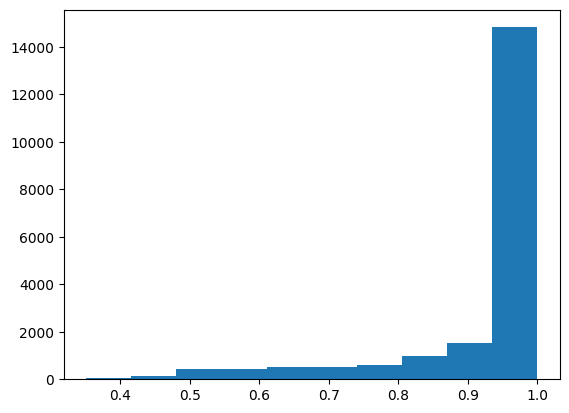

In [ ]:
# Visualisasi distribusi confidence score dari model
# Digunakan untuk menentukan threshold filtering
plt.hist(df['confidence_score'])
plt.show()

Berdasarkan visualisasi distribusi *confidence score*, terlihat bahwa mayoritas prediksi model memiliki nilai di atas **0.90**. Oleh karena itu, dipilih nilai **threshold sebesar 0.95** agar hanya prediksi dengan tingkat keyakinan yang sangat tinggi yang digunakan dalam dataset akhir.

In [ ]:
# Hanya mengambil prediksi dengan confidence >= 95%
df = df[df['confidence_score'] >= 0.95]
df['sentiment'].value_counts()

,count
sentiment,
negative,9015
positive,4918
neutral,362


# Save Labelled Data

Dataset yang telah melalui proses pelabelan dan filtering kemudian disimpan untuk digunakan pada tahap analisis sentimen selanjutnya.

In [ ]:
# Menghapus kolom confidence_score dan menyimpan dataset ke file CSV
df.drop(columns='confidence_score').to_csv("labelled_review_bsi_mobile.csv", index=False)